In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Decimal Dataset**

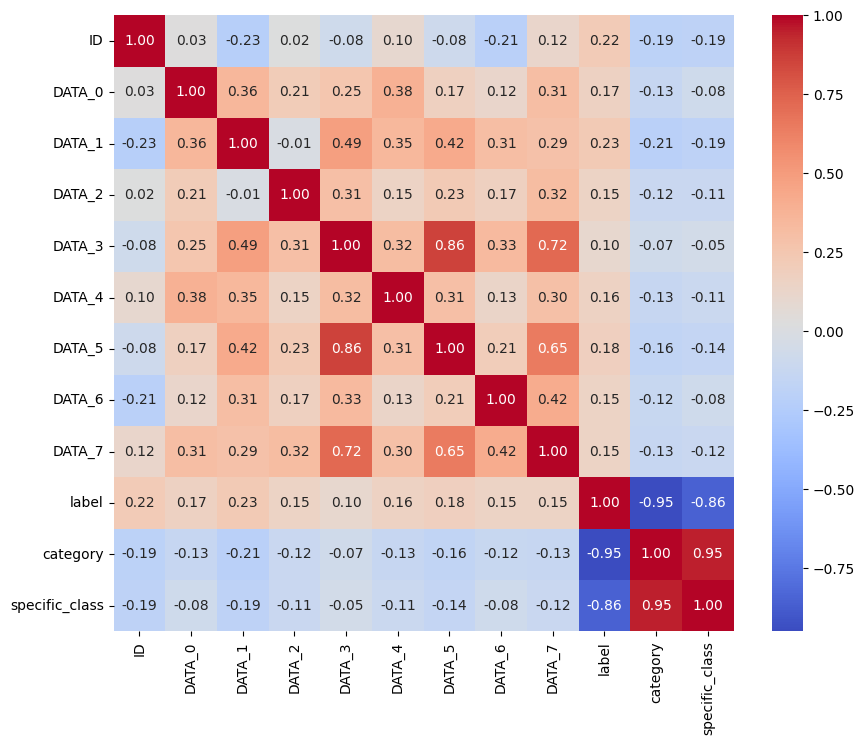

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/CICIoV2024/decimal.csv")

# Convert categorical columns to numeric using label encoding
label_encoders = {}
for column in df.select_dtypes(include=[object]).columns:
    label_encoders[column] = LabelEncoder()
    df[column] = label_encoders[column].fit_transform(df[column])

# Calculate the correlation matrix
corr = df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


In [ ]:
# Function to calculate entropy
def calculate_entropy(column):
    # Get the counts of unique values
    value_counts = column.value_counts()
    # Calculate probabilities
    probabilities = value_counts / len(column)
    # Calculate entropy
    return entropy(probabilities)

# Calculate entropy for each feature
entropies = df.apply(calculate_entropy)

# Rank features based on entropy
entropies_sorted = entropies.sort_values(ascending=False)

# Display the ranked features
print(entropies_sorted)


ID                3.677591
DATA_2            2.974033
DATA_0            2.716809
DATA_1            2.479551
DATA_4            2.397676
DATA_3            2.296856
DATA_6            2.057165
DATA_5            1.882827
DATA_7            1.754922
specific_class    0.571172
category          0.476702
label             0.388290
dtype: float64


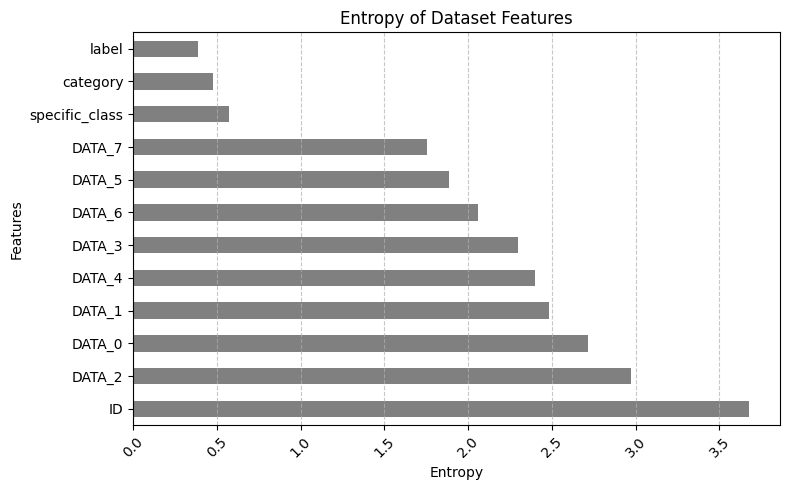

In [ ]:
# Plotting the entropy values
plt.figure(figsize=(8, 5))
entropies_sorted.plot(kind='barh', color='gray')
plt.title('Entropy of Dataset Features')
plt.ylabel('Features')
plt.xlabel('Entropy')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## **Hexadecimal Dataset**

<ipython-input-25-f0e1d38253ec>:7: DtypeWarning: Columns (1,5,7,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/CICIoV2024/hexadecimal.csv")


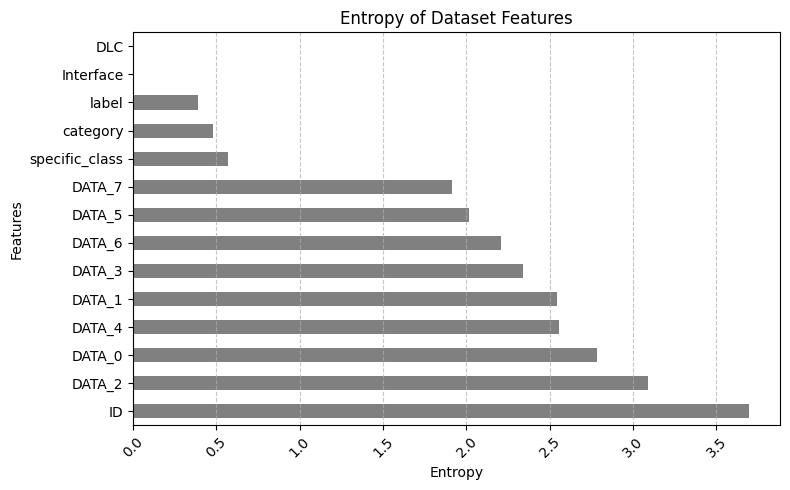

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/CICIoV2024/hexadecimal.csv")

# Function to calculate entropy
def calculate_entropy(column):
    # Get the counts of unique values
    value_counts = column.value_counts()
    # Calculate probabilities
    probabilities = value_counts / len(column)
    # Calculate entropy
    return entropy(probabilities)

# Calculate entropy for each feature
entropies = df.apply(calculate_entropy)

# Rank features based on entropy
entropies_sorted = entropies.sort_values(ascending=False)

# Plotting the entropy values
plt.figure(figsize=(8, 5))
entropies_sorted.plot(kind='barh', color='gray')
plt.title('Entropy of Dataset Features')
plt.ylabel('Features')
plt.xlabel('Entropy')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## **Binary Dataset**

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/CICIoV2024/binary.csv")
df.head()

,ID0,ID1,ID2,ID3,ID4,ID5,ID6,ID7,ID8,ID9,...,DATA_710,DATA_711,DATA_712,DATA_713,DATA_714,DATA_715,DATA_716,label,category,specific_class
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
2,0,0,0,0,0,0,0,1,0,0,...,1,1,1,1,1,1,1,BENIGN,BENIGN,BENIGN
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
4,0,0,0,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN


ID11       0.693111
ID12       0.692670
ID15       0.691158
ID16       0.690914
ID7        0.682505
             ...   
DATA_78    0.000000
DATA_74    0.000000
DATA_75    0.000000
DATA_76    0.000000
DATA_77    0.000000
Length: 156, dtype: float64


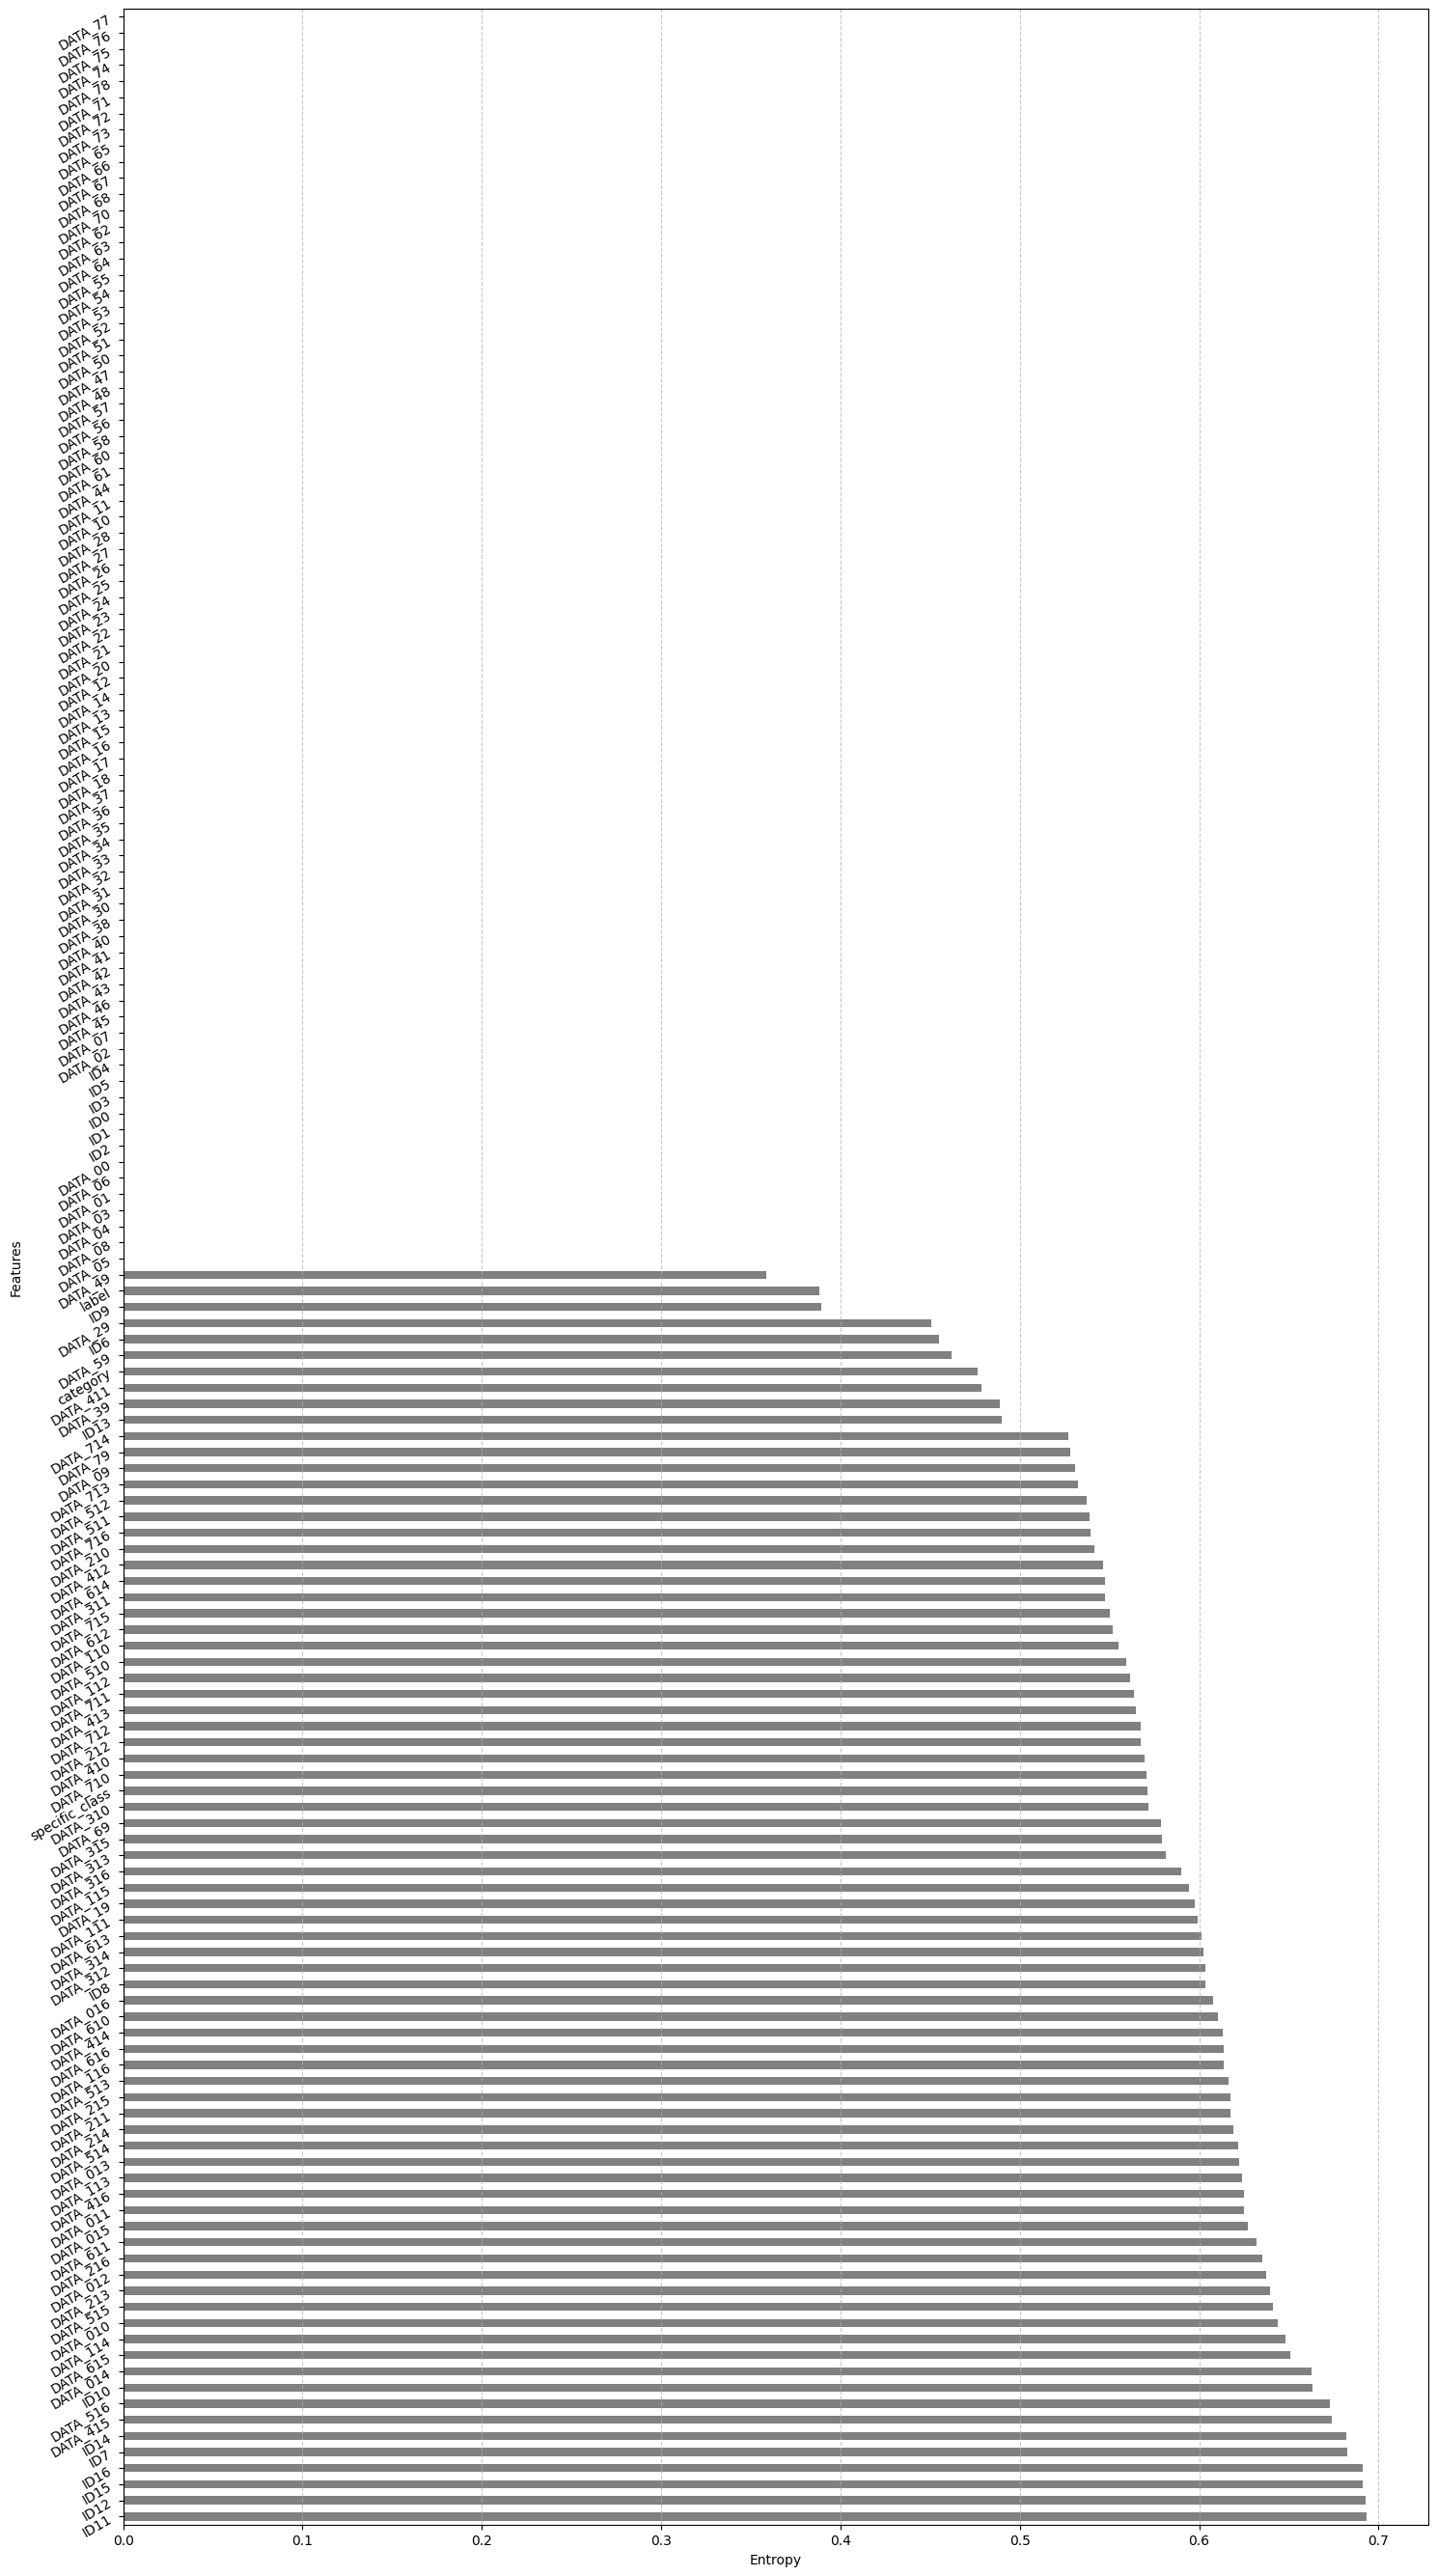

In [ ]:
# Function to calculate entropy
def calculate_entropy(column):
    # Get the counts of unique values
    value_counts = column.value_counts()
    # Calculate probabilities
    probabilities = value_counts / len(column)
    # Calculate entropy
    return entropy(probabilities)

# Calculate entropy for each feature
entropies = df.apply(calculate_entropy)

# Rank features based on entropy
entropies_sorted = entropies.sort_values(ascending=False)

# Display the ranked features
print(entropies_sorted)

# Determine figure size based on the number of features
num_features = len(entropies_sorted)
fig_height = max(8, num_features * 0.3)  # Adjust minimum height for visibility

# Plotting the entropy values with swapped axes
plt.figure(figsize=(15, fig_height-20))  # Adjust width and height based on your preference
entropies_sorted.plot(kind='barh', color='gray')  # Use kind='barh' for horizontal bar plot
#plt.title('Entropy of Dataset Features')
plt.xlabel('Entropy')
plt.ylabel('Features')
# Adjust Y-axis label orientation
plt.yticks(rotation=30)   # rotate labels to avoid overlap
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Adjust grid to be on x-axis
plt.tight_layout()
plt.show()


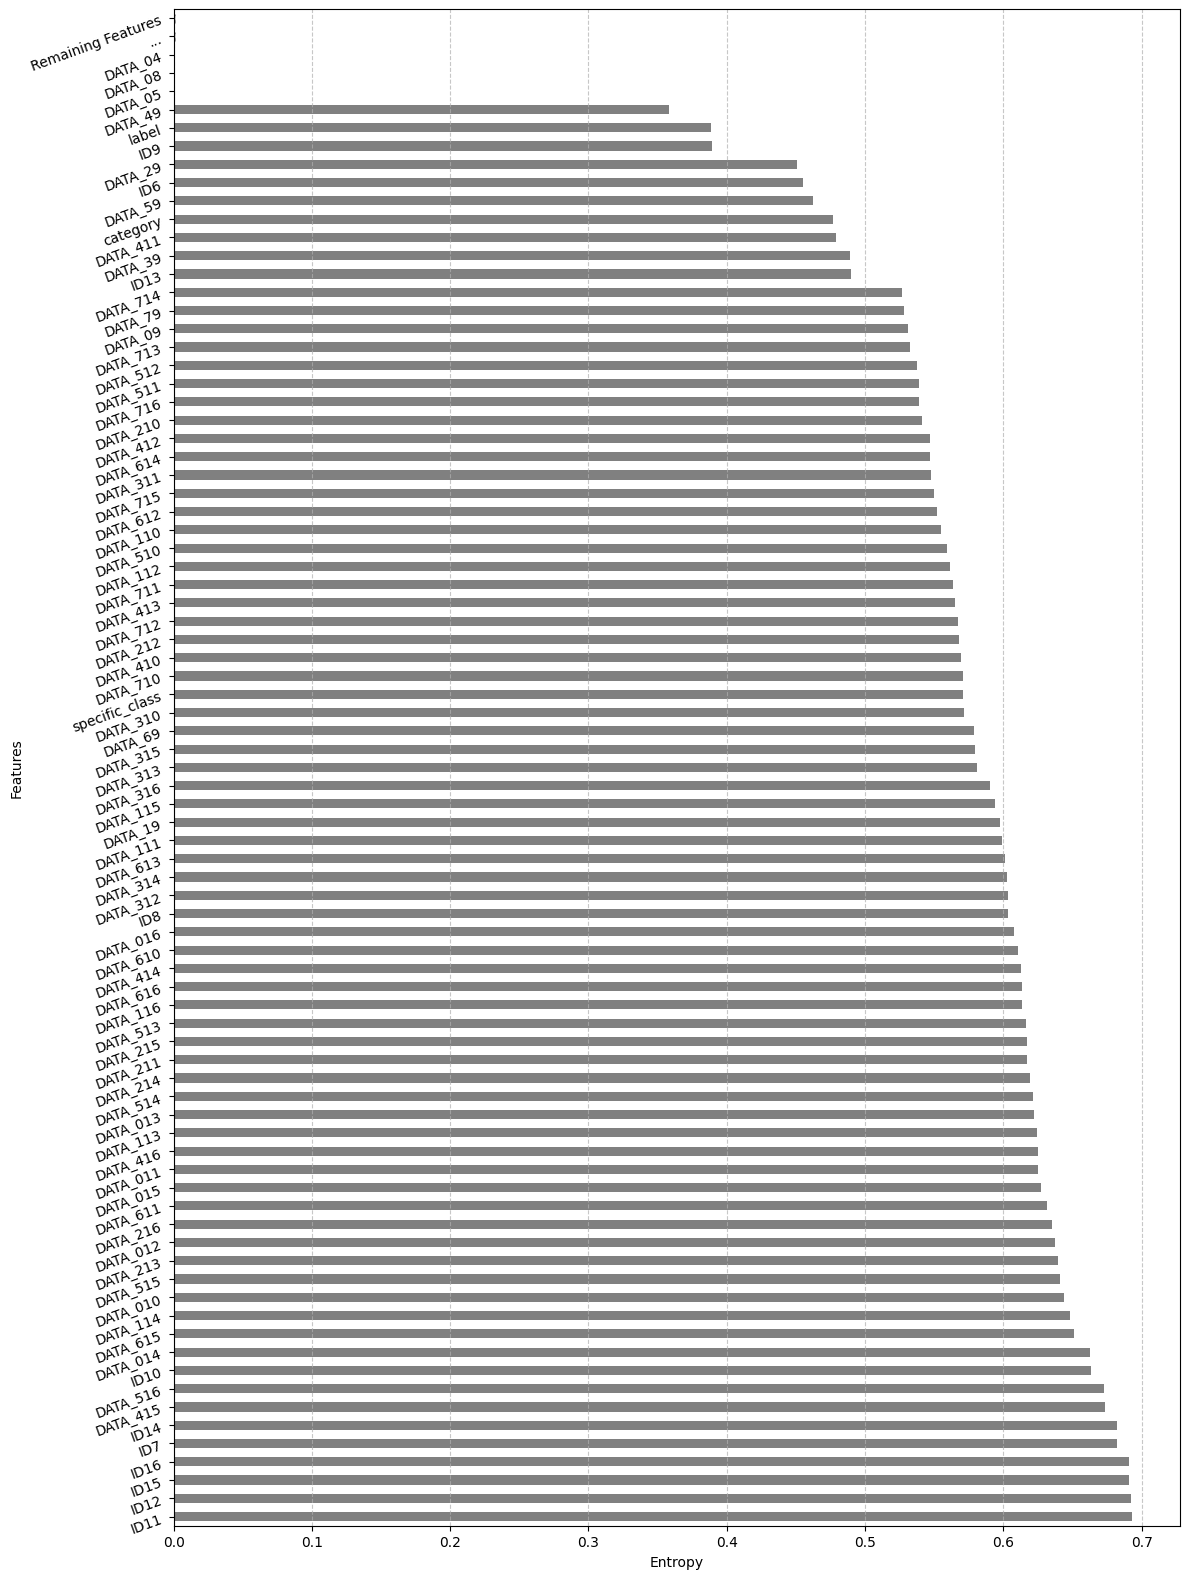

In [ ]:
# Function to calculate entropy
def calculate_entropy(column):
    value_counts = column.value_counts()
    probabilities = value_counts / len(column)
    return entropy(probabilities)

# Calculate entropy for each feature
entropies = df.apply(calculate_entropy)

# Sort features by entropy
entropies_sorted = entropies.sort_values(ascending=False)

# Separate non-zero and zero entropy features
non_zero_entropy = entropies_sorted[entropies_sorted > 0]
zero_entropy = entropies_sorted[entropies_sorted == 0]

# Keep only a few zero-entropy features for display
num_show_zero = 3   # number of zero-entropy features to show

shown_zero = zero_entropy.head(num_show_zero)

# Create placeholder entries for dotted continuation
remaining_placeholder = pd.Series(
    [0, 0],
    index=["...", "Remaining Features"]
)

# Combine all data
final_plot_data = pd.concat([
    non_zero_entropy,
    shown_zero,
    remaining_placeholder
])

# Dynamic figure height
fig_height = max(6, len(final_plot_data) * 0.3)

# Plot
plt.figure(figsize=(12, fig_height-9))

ax = final_plot_data.plot(
    kind='barh',
    color='gray'
)

# Make dotted placeholders visually different
bars = ax.patches

# Last two bars are placeholders
bars[-1].set_linestyle('--')
bars[-1].set_edgecolor('black')
bars[-1].set_facecolor('white')

bars[-2].set_linestyle('--')
bars[-2].set_edgecolor('black')
bars[-2].set_facecolor('white')

# Labels
plt.xlabel('Entropy')
plt.ylabel('Features')

# Rotate labels slightly
plt.yticks(rotation=20)

# Grid
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Define entropy threshold
entropy_threshold = 0.1

# Remove low entropy features
high_entropy_features = entropies[entropies >= entropy_threshold].index
df_high_entropy = df[high_entropy_features]

# Save the new DataFrame to a CSV file
df_high_entropy.to_csv("/content/drive/MyDrive/CICIoV2024/binary_featureExt.csv", index=False)

# Display the first few rows of the new DataFrame
print(df_high_entropy.head())


   ID6  ID7  ID8  ID9  ID10  ID11  ID12  ID13  ID14  ID15  ...  DATA_710  \
0    0    0    0    0     1     0     0     0     0     0  ...         0   
1    1    0    0    0     0     1     0     1     1     0  ...         0   
2    0    1    0    0     0     0     1     0     1     1  ...         1   
3    0    0    0    1     0     0     0     0     0     1  ...         0   
4    0    1    1    1     0     1     0     1     0     0  ...         0   

   DATA_711  DATA_712  DATA_713  DATA_714  DATA_715  DATA_716   label  \
0         0         0         0         0         0         0  BENIGN   
1         0         0         0         0         0         0  BENIGN   
2         1         1         1         1         1         1  BENIGN   
3         0         0         0         0         0         0  BENIGN   
4         0         0         0         0         0         0  BENIGN   

   category  specific_class  
0    BENIGN          BENIGN  
1    BENIGN          BENIGN  
2    BENIGN   

ID11       0.693111
ID12       0.692670
ID15       0.691158
ID16       0.690914
ID7        0.682505
             ...   
ID6        0.455131
DATA_29    0.450811
ID9        0.389460
label      0.388290
DATA_49    0.358395
Length: 78, dtype: float64


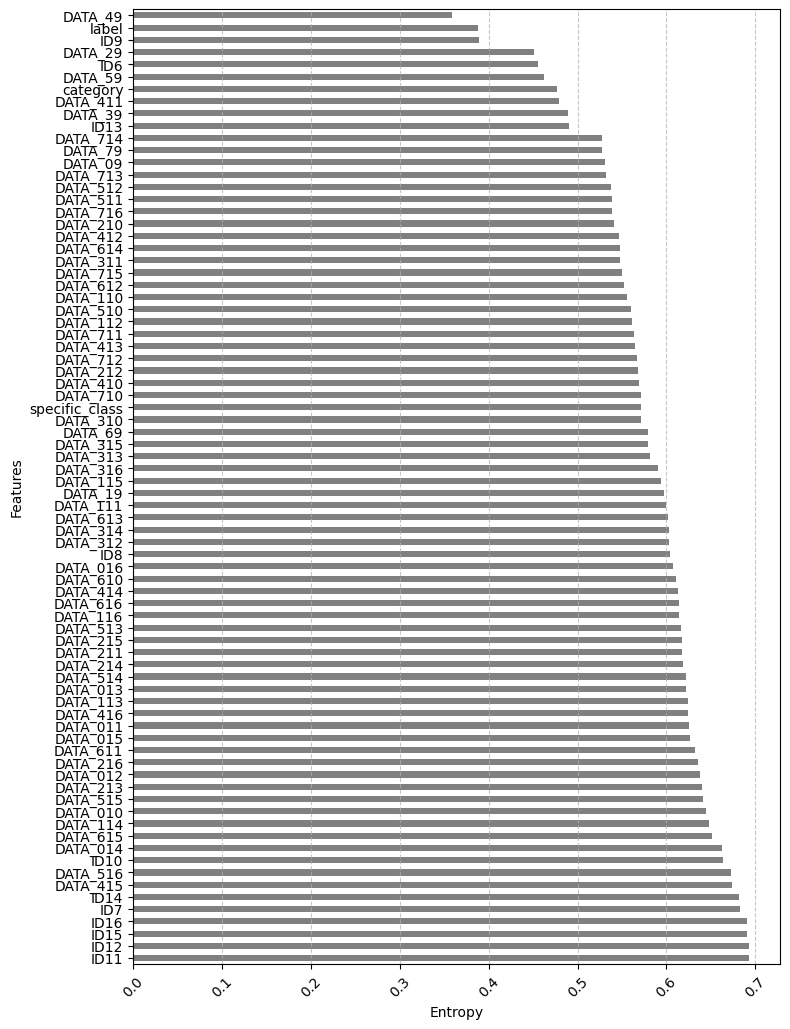

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/CICIoV2024/binary_featureExt.csv")

# Function to calculate entropy
def calculate_entropy(column):
    # Get the counts of unique values
    value_counts = column.value_counts()
    # Calculate probabilities
    probabilities = value_counts / len(column)
    # Calculate entropy
    return entropy(probabilities)

# Calculate entropy for each feature
entropies = df.apply(calculate_entropy)

# Rank features based on entropy
entropies_sorted = entropies.sort_values(ascending=False)

# Display the ranked features
print(entropies_sorted)

# Determine figure size based on the number of features
num_features = len(entropies_sorted)
fig_height = max(8, num_features * 0.3)  # Adjust minimum height for visibility

# Plotting the entropy values
plt.figure(figsize=(8, fig_height-13))
entropies_sorted.plot(kind='barh', color='gray')
plt.title('')
plt.xlabel('Entropy')
plt.ylabel('Features')
plt.xticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
